# <center>**INFO-6149 (26W) Machine Learning Security**</center>
## <center>**Project: Attack Detection and Defense**</ceneter>

## <center>**Professor: Bestan Maaroof**</center>
## <center>**Group: 05**</center>
### Group Member: 

###   1. Yun-Jiung Wang - 1256222 
###   2. Allyson Fuller - 0763664 
###   3. Gitanshu Gitanshu - 1352882 



#### Import Libs

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

# SecML related
from secml.array import CArray
from secml.ml.classifiers import CClassifierPyTorch
from secml.ml.peval.metrics import CMetricAccuracy

import time

### Part 1:  Detecting Data Poisoning and Adversarial Attacks in Machine Learning 
#### Phase 1: Dataset Selection and Preprocessing 

##### Load the dataset

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_train_ds = datasets.GTSRB(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

full_test_ds = datasets.GTSRB(
    root="./data",
    split="test",
    transform=transform,
    download=True
)

#### Data Pre-Processing

In [3]:
# Stratified Split
def get_data(dataset, n_samples):
    labels = [s[1] for s in dataset._samples]
    indices = np.arange(len(dataset))
    # make sure every label could be trained
    idx, _ = train_test_split(indices, train_size=n_samples,shuffle=True, stratify=labels, random_state=42)
    return idx

train_idx = get_data(full_train_ds, 5000)
test_idx = get_data(full_test_ds, 1000)

# Create Subset
train_subset = Subset(full_train_ds, train_idx)
test_subset = Subset(full_test_ds, test_idx)

### Phase 2: Building a Machine Learning Model 

In [4]:
class GTSRB_CNN(nn.Module):
    def __init__(self):
        super(GTSRB_CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 43)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = GTSRB_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# change to SECML
clf = CClassifierPyTorch(model=model, loss=criterion, optimizer=optimizer, 
                         input_shape=(3, 32, 32), epochs=5, batch_size=32)

def subset_to_carray(subset):
    x_list, y_list = [], []
    for img, lbl in subset:
        x_list.append(img.numpy().flatten())
        y_list.append(lbl)
    return CArray(np.array(x_list)), CArray(np.array(y_list))

X_train, y_train = subset_to_carray(train_subset)
X_test, y_test = subset_to_carray(test_subset)

#### Train the Model

In [5]:
print("start training Baseline Model...")
clf.fit(X_train, y_train)

start training Baseline Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

#### Baseline Evaluation

In [6]:
y_pred = clf.predict(X_test)
metrix = CMetricAccuracy()
acc = metrix.performance_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.4f}")

Baseline Accuracy: 0.7610


#### Confusion Matrix: Showing top 5 best and worst 5 classes

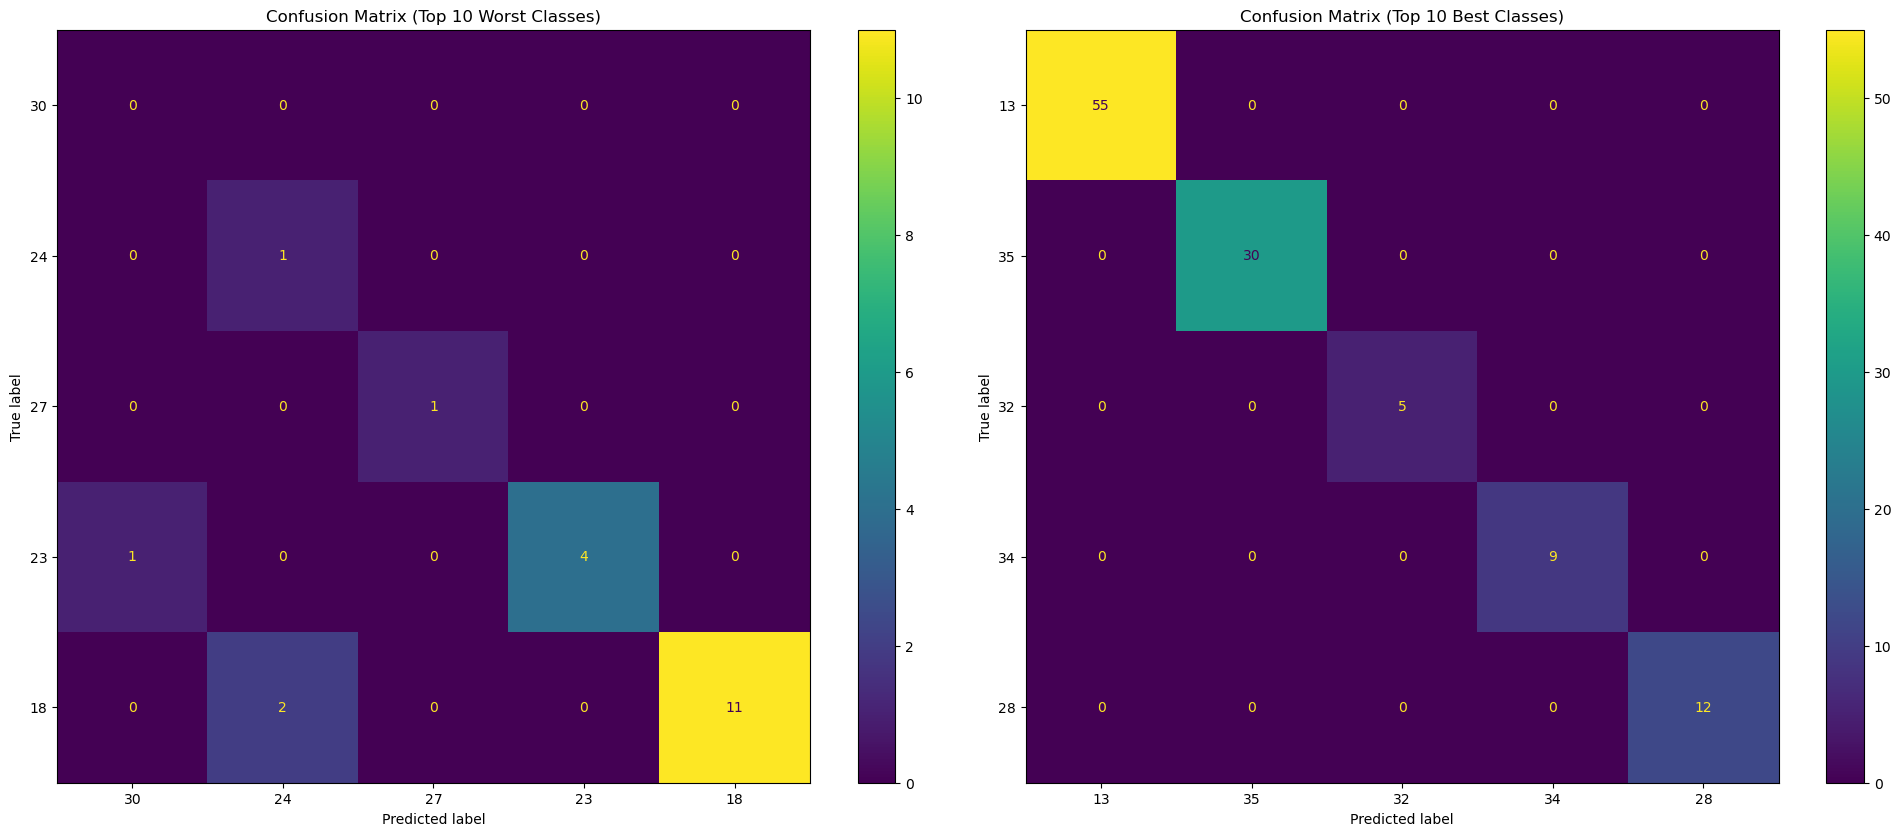

In [7]:
# Convert CArray to numpy to draw the confusion matrix
y_test_np = y_test.tondarray()
y_pred_np = y_pred.tondarray()

# Confusion Matrix
confs = confusion_matrix(y_test_np, y_pred_np)

#Graph
per_class_acc = confs.diagonal() / confs.sum(axis=1)


worst_idx = np.argsort(per_class_acc)[:5]   # Top 5 classes
best_idx = np.argsort(per_class_acc)[-5:]    # Worst 5 classes

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Worst 5
worst_confs = confs[np.ix_(worst_idx, worst_idx)]
ConfusionMatrixDisplay(confusion_matrix=worst_confs,
                       display_labels=worst_idx).plot(ax=axes[0], colorbar=True)
axes[0].set_title("Confusion Matrix (Top 10 Worst Classes)")

# Best 10
best_confs = confs[np.ix_(best_idx, best_idx)]
ConfusionMatrixDisplay(confusion_matrix=best_confs,
                       display_labels=best_idx).plot(ax=axes[1], colorbar=True)
axes[1].set_title("Confusion Matrix (Top 10 Best Classes)")

plt.tight_layout()
plt.show()

### Phase 3: Training-Time Attacks (Data Poisoning):

 **Poisoning Attack Implementation** 

Inject malicious samples into training data using one of: 

Label-flipping attacks 

Any of the clean-label backdoor attacks 

maintain attack budget (<15% training data contamination) 


**Poisoned Model Evaluation**

Retrain model on contaminated dataset 

Compare performance degradation on: 

Clean test set 

Poisoned validation samples 

Original validation set 

### Phase 4: Inference-Time Attacks (Adversarial Examples) 

Adversarial Attack Generation 

Implement two distinct attack methods: 

White-box: FGSM/PGD/C&W/DeepFool 

Black-box: Surrogate model 

Generate adversarial test sets with controlled perturbation budgets (ε ≤ 0.1) 

Attack Impact Analysis 

Quantify robustness drop using: 

Adversarial success rate 

Confidence score distributions 

Per-class vulnerability analysis 

### Phase 5: Comprehensive Evaluation 

Cross-Attack Susceptibility 

Test poisoned model against unseen attack vectors 

Analyze transferability between attack methods 

Vulnerability Report 

Create visualization: Security Curve for accuracy with both perturbations number and number of poisoned samples. 

Document failure modes and high-risk decision boundaries 

## **Part 2:  Defending Against Data Poisoning and Adversarial Attacks in Machine Learning**

### **Phase 1: Poisoning Defense Implementation**

In [8]:
# Converting CArray into nympy
X_train_np = X_train.tondarray()
y_train_np = y_train.tondarray()

X_test_np = X_test.tondarray()
y_test_np = y_test.tondarray()

In [9]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
preds = iso.fit_predict(X_train_np)

mask = preds == 1
X_train_clean = X_train_np[mask]
y_train_clean = y_train_np[mask]

print("Original:", X_train_np.shape)
print("After Cleaning:", X_train_clean.shape)

Original: (5000, 3072)
After Cleaning: (4500, 3072)


In [11]:
# Robust Model (Dropout)
class GTSRB_CNN_Defense(nn.Module):
    def __init__(self):
        super(GTSRB_CNN_Defense, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),   # defense
            nn.Linear(128, 43)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Train clean model
model = GTSRB_CNN_Defense()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

clf = CClassifierPyTorch(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    epochs=10,  
    batch_size=32
)

clf.fit(CArray(X_train_clean), CArray(y_train_clean))

GTSRB_CNN_Defense(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

### **Phase 2: Adversarial Defense Strategies**

In [12]:
# FGSM Attack
def fgsm_attack(model, x, y, epsilon=0.03):
    model.eval()
    
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)
    
    model.zero_grad()
    loss.backward()

    x_adv = x_tensor + epsilon * x_tensor.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach().numpy().reshape(x.shape)

In [16]:
# PGD Attack
def pgd_attack(model, x, y, epsilon=0.03, alpha=0.005, iters=5):
    x_adv = torch.tensor(x.reshape(-1,3,32,32)).float()
    y_tensor = torch.tensor(y).long()

    for i in range(iters):
        x_adv.requires_grad = True
        
        outputs = model(x_adv)
        loss = nn.CrossEntropyLoss()(outputs, y_tensor)

        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()
        x_adv = torch.clamp(x_adv, 0, 1).detach()

    return x_adv.numpy().reshape(x.shape)

In [17]:
# Generating PGD in batches 
batch_size = 256
X_pgd_list = []

for i in range(0, len(X_train_clean), batch_size):
    x_batch = X_train_clean[i:i+batch_size]
    y_batch = y_train_clean[i:i+batch_size]

    x_adv_batch = pgd_attack(model, x_batch, y_batch)
    X_pgd_list.append(x_adv_batch)

X_pgd = np.vstack(X_pgd_list)

In [18]:
# Combine clean + adversarial to balanced it
X_combined = np.vstack((X_train_clean, X_pgd[:len(X_train_clean)]))
y_combined = np.hstack((y_train_clean, y_train_clean))

# Retrain with adversarial training
clf.fit(CArray(X_combined), CArray(y_combined))

GTSRB_CNN_Defense(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

In [19]:
# Randomized Smoothing
def randomized_smoothing(x, sigma=0.01):
    noise = np.random.normal(0, sigma, x.shape)
    return np.clip(x + noise, 0, 1)

### **Phase 3: Defense Evaluation**

In [20]:
metric = CMetricAccuracy()

# Clean Accuracy
y_pred_clean = clf.predict(CArray(X_test_np))
acc_clean = metric.performance_score(CArray(y_test_np), y_pred_clean)
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")

Clean Accuracy After Defense: 0.7800


In [21]:
# Adversarial Accuracy
X_test_adv = fgsm_attack(model, X_test_np, y_test_np)

y_pred_adv = clf.predict(CArray(X_test_adv))
acc_adv = metric.performance_score(CArray(y_test_np), y_pred_adv)
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")

Adversarial Accuracy After Defense: 0.2030


In [22]:
# Smoothed Accuracy
X_test_smooth = randomized_smoothing(X_test_np)

y_pred_smooth = clf.predict(CArray(X_test_smooth))
acc_smooth = metric.performance_score(CArray(y_test_np), y_pred_smooth)
print(f"Smoothed Accuracy: {acc_smooth:.4f}")

Smoothed Accuracy: 0.7770


In [23]:
# Attack Success Rate 
attack_success = 1 - acc_adv
print(f"Attack Success Rate: {attack_success:.4f}")

Attack Success Rate: 0.7970


In [24]:
# Gradient Sensitivity 
def gradient_sensitivity(model, x, y):
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)

    loss.backward()
    return x_tensor.grad.abs().mean().item()

sens = gradient_sensitivity(model, X_test_np[:100], y_test_np[:100])
print("Gradient Sensitivity:", sens)

Gradient Sensitivity: 0.0005508645554073155


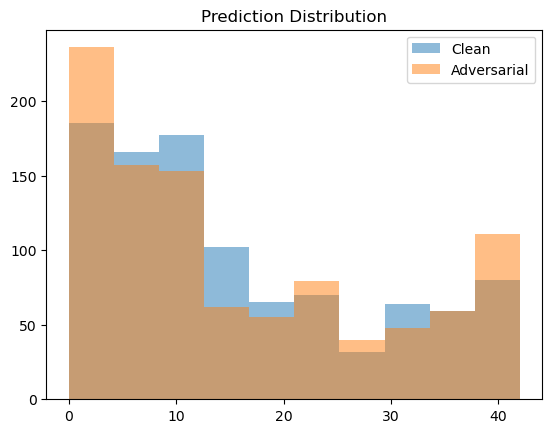

In [25]:
# Prediction Distribution
import matplotlib.pyplot as plt

plt.hist(y_pred_clean.tondarray(), alpha=0.5, label="Clean")
plt.hist(y_pred_adv.tondarray(), alpha=0.5, label="Adversarial")
plt.legend()
plt.title("Prediction Distribution")
plt.show()

In [26]:
print(f"Baseline Accuracy: {acc:.4f}")
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")
print(f"Smoothed Accuracy: {acc_smooth:.4f}")
print(f"Attack Success Rate: {attack_success:.4f}")

Baseline Accuracy: 0.7610
Clean Accuracy After Defense: 0.7800
Adversarial Accuracy After Defense: 0.2030
Smoothed Accuracy: 0.7770
Attack Success Rate: 0.7970


### **Phase 4: Reporting & Advanced Exploration**